In [1]:
#Import Notebooks
import pandas as pd
import seaborn as sns

In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import pprint

from sklearn.tree import DecisionTreeClassifier # create a decision tree
from sklearn.tree import plot_tree # tree plotting
from sklearn.tree import export_text # tree classification rules in text format

from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm ## Generate coefficient statistics for logistic regression
from sklearn.svm import LinearSVC, SVC

# Evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay # accuracy and confusion matrix
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report # precision, recall, and f1
from sklearn.metrics import RocCurveDisplay, roc_auc_score # roc and auc

from sklearn.model_selection import train_test_split # Holdout validation
from sklearn.model_selection import StratifiedKFold, cross_validate # KFold cross validation
from sklearn.metrics import accuracy_score # Obtain the accuracy_score

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV

%precision 4

'%.4f'

In [3]:
df = pd.read_csv("loan.csv", engine = 'python', on_bad_lines = 'skip') 

In [4]:
df.shape
df["loan_amnt"].mean()

14755.2646

## STEP 1: Data Preperation 
- Remove missing columns
- Remove missing rows
- replace numeric values with median and categorical with mode
- create indicator columns into dummy variables
- created defualt into binary variable

In [5]:
def data_prep(df):

    clean_loan = df.copy()

    # Remove columns with >50% missing values(from lab 5)
    col_threshold = 0.50
    clean_loan = clean_loan.loc[:, clean_loan.isnull().mean() < col_threshold]

    #Remove rows with 80 percent of missing values(lab 5)
    row_threshold = int(clean_loan.shape[1] * 0.20)
    clean_loan = clean_loan.dropna(thresh=row_threshold)

    # Fill missing values (From lab 3, 5 and 7)
    for col in clean_loan.columns:
        if clean_loan[col].dtype in ["float64", "int64"]:
            clean_loan[col] = clean_loan[col].fillna(clean_loan[col].median())
        else:
            clean_loan[col] = clean_loan[col].fillna(clean_loan[col].mode()[0])
            
    #make idicator varibales into dummy variables (lab 9)
    indicator_cols = ["hardship_flag", "debt_settlement_flag",
                     "initial_list_status", "disbursement_method", "application_type"]

    for col in indicator_cols:
        if col in clean_loan.columns:
            clean_loan[col] = clean_loan[col].map({"*": 1, "N": 0})
            clean_loan[col] = clean_loan[col].fillna(0)
            clean_loan[col] = clean_loan[col].astype(int)
        return clean_loan

    return df


In [6]:
#Dropping columns (from lab 5)
columns_dropped = ["recoveries", "collection_recovery_fee", "out_prncp_inv", "total_rec_prncp", "total_pymnt_inv", "total_pymnt", "desc", "mths_since_last_record",
                    "annual_inc_joint", "dti_joint", "verification_status_joint", "tot_coll_amt",
                    "tot_cur_bal", "open_acc_6m", "open_il_6m", "open_il_12m", "open_il_24m", "mths_since_rcnt_il",
                    "total_bal_il", "il_util", "open_rv_12m", "open_rv_24m", "max_bal_bc", "all_util",
                    "total_rev_hi_lim", "inq_fi", "total_cu_tl", "inq_last_12m", "mths_since_last_major_derog", "next_pymnt_d",
                    "mths_since_last_delinq", "emp_title", "emp_length", "earliest_cr_line", "revol_util", "last-pymnt_d",
                    "last_credit_pull_d", "last_pymnt_d", "addr_state", "url", "id", "member_id", "issue_d", "earliest_cr_line", 
                    "last_pymnt_d", "last_credit_pull_d", "sub_grade", "pymnt_plan_ind", "title", "zip_code", "pymnt_plan_ind"]

## ADDED: recoveries and on

df = df.drop(columns_dropped, axis=1, errors = 'ignore')

In [7]:
#Defualt risk: variable indicator 
#Coverting default into a binary variable fully paid, default
likely_default = [
    "Charged Off",
    "Default",
    "Late (31-120 days)",
    "Late (16-30 days)",
    "Does not meet the credit policy. Status:Fully Paid",
    "Does not meet the credit policy. Status:Charged Off",
]

# Making binary variable ---> Use of ChatGPT 
df["default_risk"] = df["loan_status"].apply(
    lambda x: 1 if x in likely_default else 0
)

df = df[~df["loan_status"].isin(["In Grace Period", "Issued"])]
df = df.drop(columns=["loan_status"])

In [8]:
df_clean = data_prep(df)

In [9]:
df_clean.isnull().sum().sum()

np.int64(0)

In [10]:
df_clean["default_risk"].value_counts()

default_risk
0    809502
1     63164
Name: count, dtype: int64

In [11]:
df_clean.isnull().sum()

loan_amnt                     0
funded_amnt                   0
funded_amnt_inv               0
term                          0
int_rate                      0
installment                   0
grade                         0
home_ownership                0
annual_inc                    0
verification_status           0
pymnt_plan                    0
purpose                       0
dti                           0
delinq_2yrs                   0
inq_last_6mths                0
open_acc                      0
pub_rec                       0
revol_bal                     0
total_acc                     0
initial_list_status           0
out_prncp                     0
total_rec_int                 0
total_rec_late_fee            0
last_pymnt_amnt               0
collections_12_mths_ex_med    0
policy_code                   0
application_type              0
acc_now_delinq                0
default_risk                  0
dtype: int64

In [12]:
#Creating a balance sample set --Use of chatgpt 
df_0 = df_clean[df_clean["default_risk"] == 0].sample(n=5000, random_state=1)
df_1 = df_clean[df_clean["default_risk"] == 1].sample(n=5000, random_state=1)
df_balanced = pd.concat([df_0, df_1])
df_balanced = df_balanced.sample(frac=1, random_state=1).reset_index(drop=True)
df_clean = df_balanced.copy()

In [13]:
grade_order = sorted(df_clean['grade'].unique())

#Converting grade column into numerical value(enumerate- gives index, value)-->Use of chatGPT 
grade_map = {grade: idx for idx, grade in enumerate(grade_order)}
df_clean['grade'] = df_clean['grade'].map(grade_map)

In [14]:
#converting strings to floats
term_map = {' 36 months': 36, ' 60 months':60}
df_clean['term'] = df_clean['term'].map(term_map)

In [15]:
from sklearn.preprocessing import OrdinalEncoder

#ordinal encoding creating a list of columns with cat text values ---> Use of ChatGPT
nominal_cols = ['home_ownership', 'verification_status', 'purpose']
encoder = OrdinalEncoder()
df_clean[nominal_cols] = encoder.fit_transform(df_clean[nominal_cols])

In [16]:
Indicator_columns = ["pymnt_plan", "hardship_flag", "debt_settlement_flag",
                     "initial_list_status", "disbursement_method", "application_type"]

for col in Indicator_columns:
    if col in df.columns:
        df_clean[col + "_ind"] = df_clean[col].map({
            'Y': 1, 'N': 0, 'y':1, 'n':0,
            'w':1, 'f':0,
            'Cash':1, 'DirectPay':0,
            'JOINT':1, 'INDIVIDUAL':0
        })
        df_clean = df_clean.drop(columns=[col])


In [17]:
# Define class labels
target_name = "default_risk"
X = df_clean.drop(target_name, axis = 1)
y = df_clean[target_name]

fnames = list(X.columns)
print(fnames)

findex = X.index
cnames = np.sort(y.unique())
cnames = [str(x) for x in cnames]

print(cnames)

['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'home_ownership', 'annual_inc', 'verification_status', 'purpose', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'total_acc', 'out_prncp', 'total_rec_int', 'total_rec_late_fee', 'last_pymnt_amnt', 'collections_12_mths_ex_med', 'policy_code', 'acc_now_delinq', 'pymnt_plan_ind', 'initial_list_status_ind', 'application_type_ind']
['0', '1']


In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                  test_size = 0.2, #20% for testing and 80% for training
                                                  random_state = 1,
                                                  stratify = y) # Make sure class label distributions are comparable

In [19]:
print(X_train.shape, X_test.shape)
print(y_train.shape, y_test.shape)

(8000, 28) (2000, 28)
(8000,) (2000,)


In [20]:
# finding categorical columns with 50 unique values--> help from TA 
high_card = [col for col in X.columns
             if X[col].dtype == 'object' and X[col].nunique() > 50]

X_reduced = X.drop(columns=high_card)

In [21]:
from sklearn.preprocessing import OrdinalEncoder

#converting text values into numbers using encoder--> help from TA
categorical_cols = X.select_dtypes(include="object").columns
oe = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X[categorical_cols] = oe.fit_transform(X[categorical_cols])

In [22]:
df_clean.to_csv("loan_cleaned.csv", index = False)

## STEP 2: Modeling

### 1. Decision Tree

In [23]:
MAX_DEPTH = 4  # Reduced to prevent overfitting
CRITERION = "entropy"
RANDOM_STATE = 1
MIN_SAMPLES_SPLIT = 5  # Add regularization
MIN_SAMPLES_LEAF = 10   # Add regularization


In [24]:
def viz_tree_fig(dt, fnames, cnames, figname):
    fig, ax = plt.subplots(figsize = (10, 10))  # whatever size you want
    plot_tree(dt,
              feature_names = fnames,
              class_names = cnames,
              rounded = True,
              filled = True,
              ax = ax)
    fig.savefig(figname)

# Define a function to print decision tree rules and save it in a text file
def save_tree_text(dt, fnames, txtname):
    r = export_text(dt, feature_names=fnames, show_weights = True)
    print(r)
    with open(txtname,"w") as outfile:
        outfile.write(r)

In [25]:
#dt = DecisionTreeClassifier(max_depth = MAX_DEPTH, criterion = CRITERION, random_state = RANDOM_STATE)

#dt = DecisionTreeClassifier(max_depth = 4, min_impurity_decrease = 0.006, criterion = "entropy", random_state = 1, min_samples_split = MIN_SAMPLES_SPLIT, min_samples_leaf = MIN_SAMPLES_LEAF)
dt = DecisionTreeClassifier(max_depth = 4,
                            max_leaf_nodes = None, 
                            min_impurity_decrease = 0.006, 
                            min_samples_leaf = 10, 
                            min_samples_split = 5,
                            random_state = 1)

dt = dt.fit(X, y)


In [26]:
##### Importance Based on Decision Trees #####
importances = pd.Series(dt.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(20)

out_prncp                     0.476945
last_pymnt_amnt               0.447513
total_rec_late_fee            0.041348
int_rate                      0.034194
loan_amnt                     0.000000
pub_rec                       0.000000
initial_list_status_ind       0.000000
pymnt_plan_ind                0.000000
acc_now_delinq                0.000000
policy_code                   0.000000
collections_12_mths_ex_med    0.000000
total_rec_int                 0.000000
total_acc                     0.000000
revol_bal                     0.000000
open_acc                      0.000000
funded_amnt                   0.000000
inq_last_6mths                0.000000
delinq_2yrs                   0.000000
dti                           0.000000
purpose                       0.000000
dtype: float64

In [27]:
#viz_tree_fig(dt, fnames, cnames, "tree1.pdf")
#save_tree_text(dt, fnames, "tree1.txt")

In [28]:
y_pred_test = dt.predict(X_test)
print(f"Testing accuracy for the default decision tree is: {accuracy_score(y_test, y_pred_test):.4f}")

Testing accuracy for the default decision tree is: 0.8465


In [29]:
y_pred_train = dt.predict(X_train)
accuracy_score(y_train, y_pred_train)

0.8496

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- cluster


In [56]:
print(classification_report(y_test, y_pred_test, digits = 4))

              precision    recall  f1-score   support

           0     0.7890    0.9460    0.8604      1000
           1     0.9326    0.7470    0.8295      1000

    accuracy                         0.8465      2000
   macro avg     0.8608    0.8465    0.8450      2000
weighted avg     0.8608    0.8465    0.8450      2000



### 2. KNN

In [59]:
knn = KNeighborsClassifier(n_neighbors = 5, metric='euclidean')
knn.fit(X_train, y_train)

y_test_knn = knn.predict(X_test)
acc_knn = accuracy_score(y_test, y_test_knn)
print(f"The test data performance for the K-nearest neighbor is {acc_knn:.2%}")
print(classification_report(y_test, y_test_knn, digits = 4))

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- cluster


In [31]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, MinMaxScaler


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 3. Nueral Network

In [32]:
# Train
nn = MLPClassifier(hidden_layer_sizes = (150, 150, 100), 
                   alpha = 0.0001, # L2 penalty (regularization term) parameter. Change it to be 0.0001
                   max_iter = 5000,
                   activation = 'relu', 
                   learning_rate = "adaptive",
                   learning_rate_init = 0.1,
                   random_state = 42)
nn.fit(X_train_scaled, y_train)

# Test
y_test_nn = nn.predict(X_test_scaled)
acc_nn = accuracy_score(y_test, y_test_nn)
print(f"The test data performance for the neural network is {acc_nn:.2%}")
print(classification_report(y_test, y_test_nn, digits = 4))

The test data performance for the neural network is 82.80%
              precision    recall  f1-score   support

           0     0.7877    0.8980    0.8393      1000
           1     0.8814    0.7580    0.8151      1000

    accuracy                         0.8280      2000
   macro avg     0.8346    0.8280    0.8272      2000
weighted avg     0.8346    0.8280    0.8272      2000



### 4. Logistic Regression

In [33]:
# Train
lg= LogisticRegression(C = 0.01, # Change to 0.01 and examine the test accuracy
                       random_state = 42)
lg.fit(X_train, y_train)

# Testing
y_test_lg = lg.predict(X_test)
acc_log = accuracy_score(y_test, y_test_lg)
print(f"The test data performance for the logistic regression is {acc_log:.2%}")
print(classification_report(y_test, y_test_lg, digits = 4))

The test data performance for the logistic regression is 80.70%
              precision    recall  f1-score   support

           0     0.7771    0.8610    0.8169      1000
           1     0.8442    0.7530    0.7960      1000

    accuracy                         0.8070      2000
   macro avg     0.8106    0.8070    0.8064      2000
weighted avg     0.8106    0.8070    0.8064      2000



## Performing Ensemble

In [34]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
%precision 4

from scipy.stats import uniform, randint

# Ensemble Methods
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import VotingClassifier, StackingClassifier

# XGBoost
#from xgboost import XGBClassifier

#  Classifiers
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC, SVC

# Evaluation 
from sklearn.metrics import accuracy_score, confusion_matrix # accuracy and confusion matrix
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report # precision, recall, and f1
from sklearn.metrics import roc_auc_score # roc and auc

# Pipeline and preprocessing
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, MinMaxScaler

# Model Selection
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.feature_selection import SelectKBest, chi2, mutual_info_classif

# Ignore useless warnings (see SciPy issue #5998)
import warnings
warnings.filterwarnings("ignore")
import sklearn
print(sklearn.__version__)

1.6.1


In [35]:
# Ensemble Methods
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import VotingClassifier, StackingClassifier

In [36]:
# define individual classifier (maximize differences)
#####DECISION TREE#########
dt = DecisionTreeClassifier(max_depth = 8, 
                            random_state = 42)


#y_pred_train = dt.predict(X_train)
#print(f"Training accuracy for the default decision tree is: {accuracy_score(y_train, y_pred_train):.4f}")

# Calculate testing accuracy
#y_pred_test = dt.predict(X_test)
#print(f"Testing accuracy for the default decision tree is: {accuracy_score(y_test, y_pred_test):.4f}")



nn = MLPClassifier(hidden_layer_sizes = (150, 150, 100), 
                   alpha = 0.0001, # L2 penalty (regularization term) parameter. Change it to be 0.0001
                   max_iter = 5000,
                   activation = 'relu', 
                   learning_rate = "adaptive",
                   learning_rate_init = 0.001,
                   random_state = 1)
nn.fit(X_train_scaled, y_train)

#nn = MLPClassifier(hidden_layer_sizes = (100, 150, 100), 
                   #alpha = 0.0001, # L2 penalty (regularization term) parameter. Change it to be 0.0001
                  # max_iter = 5000,
                   #activation = 'relu', 
                   #learning_rate = "adaptive",
                   #learning_rate_init = 0.1,
                   #random_state = 1)
#knn = KNeighborsClassifier(n_neighbors = 42, 
                           #metric='euclidean')

#####LOGISTIC REGRESSION#########

lreg = LogisticRegression(random_state = 1)
#lreg = Pipeline([('poly_features', PolynomialFeatures(degree = 2)), ('logistic_regression', LogisticRegression(random_state = 42))])

svm = SVC(C = 1, 
          kernel = 'rbf', 
          gamma = 0.1,
          random_state = 42,
          probability = True)

# create an estimator
classifiers = [('decisionTree', dt),
               ('neuralNet', nn),
               ('neighbor', knn),
               ('logistic', lreg),
               ('svm', svm)]
#########
# train
voting_clf = VotingClassifier(estimators = classifiers, 
                              voting = 'hard')
voting_clf.fit(X_train, y_train)


# test
y_test_vh = voting_clf.predict(X_test)
acc_vh = accuracy_score(y_test, y_test_vh)

print(f"The test data performance for Voting (hard) is {acc_vh:.2%}")
print(classification_report(y_test, y_test_vh, digits = 4))

The test data performance for Voting (hard) is 82.55%
              precision    recall  f1-score   support

           0     0.7919    0.8830    0.8350      1000
           1     0.8678    0.7680    0.8149      1000

    accuracy                         0.8255      2000
   macro avg     0.8299    0.8255    0.8249      2000
weighted avg     0.8299    0.8255    0.8249      2000



In [37]:
# Check the individual classifier
for label, clf in classifiers:
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(label, accuracy_score(y_test, y_pred))

decisionTree 0.8485
neuralNet 0.8375
neighbor 0.7675
logistic 0.808
svm 0.5


### 1. Bagging

In [38]:
##### Bagging Classifier ##### - From Lab 10 
bag_clf = BaggingClassifier(estimator = DecisionTreeClassifier(max_depth = 10, random_state  = 1),
                            n_estimators = 100, 
                            random_state = 1)
bag_clf.fit(X_train, y_train)

# test
y_test_bag = bag_clf.predict(X_test)
acc_bag = accuracy_score(y_test, y_test_bag)

print(f"The test data performance for Bagging is {acc_bag:.2%}")
print(classification_report(y_test, y_test_bag, digits = 4))

##### Feature Importance #####
bag_imp = pd.DataFrame(list(zip(X_train.columns, np.mean([
    tree.feature_importances_ for tree in bag_clf.estimators_
], axis=0))), columns = ['feature', 'bag_imp_score']).sort_values(by = 'bag_imp_score', ascending = False)
bag_imp

The test data performance for Bagging is 85.50%
              precision    recall  f1-score   support

           0     0.8008    0.9450    0.8670      1000
           1     0.9329    0.7650    0.8407      1000

    accuracy                         0.8550      2000
   macro avg     0.8669    0.8550    0.8538      2000
weighted avg     0.8669    0.8550    0.8538      2000



,feature,bag_imp_score
21,last_pymnt_amnt,0.353857
18,out_prncp,0.349849
4,int_rate,0.060527
20,total_rec_late_fee,0.039994
19,total_rec_int,0.032358
16,revol_bal,0.022250
11,dti,0.019419
8,annual_inc,0.017266
13,inq_last_6mths,0.016891
17,total_acc,0.015455


### 2. Random Forest

In [39]:
##### Random Forest #####
rf_clf = RandomForestClassifier(max_depth = 15, max_features = 0.9, # Percentage of subset of columns in each dataset
                                n_estimators = 100, # number of trees
                                random_state = 1)
rf_clf.fit(X_train, y_train)

# test
y_test_rf = rf_clf.predict(X_test)
acc_rf = accuracy_score(y_test, y_test_rf)

print(f"The test data performance for Random Forest is {acc_rf:.2%}")
print(classification_report(y_test, y_test_rf, digits = 4))

##### Feature Importance #####
rf_imp = pd.DataFrame(list(zip(X_train.columns, rf_clf.feature_importances_)), 
                     columns = ['feature', 'rf_imp_score']).sort_values(by = 'rf_imp_score', ascending = False)
rf_imp

The test data performance for Random Forest is 85.85%
              precision    recall  f1-score   support

           0     0.8067    0.9430    0.8695      1000
           1     0.9314    0.7740    0.8454      1000

    accuracy                         0.8585      2000
   macro avg     0.8690    0.8585    0.8575      2000
weighted avg     0.8690    0.8585    0.8575      2000



,feature,rf_imp_score
18,out_prncp,0.312419
21,last_pymnt_amnt,0.282416
4,int_rate,0.064017
19,total_rec_int,0.046876
16,revol_bal,0.035743
11,dti,0.033648
20,total_rec_late_fee,0.032285
8,annual_inc,0.029133
17,total_acc,0.025686
5,installment,0.021384


### 3. Ada Boosting

In [40]:
###### Ada Boosting ######
ada_clf = AdaBoostClassifier(estimator = DecisionTreeClassifier(max_depth = 15, 
                            random_state = 1), n_estimators = 100, 
                             #algorithm = "SAMME",
                             random_state = 1)
ada_clf.fit(X_train, y_train)

# test
y_test_ada = ada_clf.predict(X_test)
acc_ada = accuracy_score(y_test, y_test_ada)

print(f"The test data performance for Adaboost is {acc_ada:.2%}")
print(classification_report(y_test, y_test_ada, digits = 4))

### Feature Importance ####
ada_imp = pd.DataFrame(list(zip(X_train.columns, ada_clf.feature_importances_)), 
                     columns = ['feature', 'ada_imp_score']).sort_values(by = 'ada_imp_score', ascending = False)
ada_imp

The test data performance for Adaboost is 84.10%
              precision    recall  f1-score   support

           0     0.8094    0.8920    0.8487      1000
           1     0.8797    0.7900    0.8325      1000

    accuracy                         0.8410      2000
   macro avg     0.8446    0.8410    0.8406      2000
weighted avg     0.8446    0.8410    0.8406      2000



,feature,ada_imp_score
18,out_prncp,1.121532e-01
16,revol_bal,1.118614e-01
8,annual_inc,1.027912e-01
19,total_rec_int,1.007826e-01
4,int_rate,9.757172e-02
11,dti,9.194166e-02
17,total_acc,6.321165e-02
5,installment,5.518765e-02
14,open_acc,4.146614e-02
21,last_pymnt_amnt,3.769622e-02


In [41]:
from xgboost import XGBClassifier

### 4. XGBoost

In [42]:
##### XGBoost #####
xg = XGBClassifier(n_estimators = 100, # number of trees
                   random_state = 1)
xg.fit(X_train, y_train)

# test
y_test_xg = xg.predict(X_test)
acc_xg = accuracy_score(y_test, y_test_xg)

print(f"The test data performance for XGBoost is {acc_xg:.2%}")
print(classification_report(y_test, y_test_xg, digits = 4))

##### Feature Importance #####
xg_imp = pd.DataFrame(list(zip(X_train.columns, xg.feature_importances_)), 
                     columns = ['feature', 'xg_imp_score']).sort_values(by = 'xg_imp_score', ascending = False)
xg_imp

The test data performance for XGBoost is 84.65%
              precision    recall  f1-score   support

           0     0.8102    0.9050    0.8550      1000
           1     0.8924    0.7880    0.8370      1000

    accuracy                         0.8465      2000
   macro avg     0.8513    0.8465    0.8460      2000
weighted avg     0.8513    0.8465    0.8460      2000



,feature,xg_imp_score
18,out_prncp,0.182582
21,last_pymnt_amnt,0.156636
20,total_rec_late_fee,0.113617
4,int_rate,0.046931
3,term,0.041519
6,grade,0.035056
13,inq_last_6mths,0.034201
1,funded_amnt,0.032352
26,initial_list_status_ind,0.029439
19,total_rec_int,0.028680


### 5. Grid search

In [43]:
# #### Grid Search ####
# bag_clf = BaggingClassifier(estimator = DecisionTreeClassifier(random_state  = 1),
#                             n_estimators = 100, 
#                             random_state = 1)
# parameters = {'estimator__max_depth': (20, 25, 30), 
#               'n_estimators': (50, 100, 200)}
# grid_bag = GridSearchCV(bag_clf, parameters, cv = 5, verbose = 3,
#                         scoring = 'accuracy', return_train_score = True)
# grid_bag.fit(X_train, y_train)

In [44]:
# #### Bagging grid accuracy #####
# print(grid_bag.best_params_)
# print(grid_bag.best_score_)
# y_grid_bag = grid_bag.predict(X_test)
# accuracy_score(y_test, y_grid_bag)

In [45]:
# #### Bagging and Pipeline #####
# bag_clf2 = Pipeline ([("poly", PolynomialFeatures(degree = 1)),
#                      ("bag", BaggingClassifier(estimator = DecisionTreeClassifier(random_state  = 1),
#                             n_estimators = 100, 
#                             random_state = 1))])
# parameters = {'bag__estimator__max_depth': (20, 25, 30), # We need to refer to pipeline step, then bagging parameter and finally decision tree parameters
#               'bag__n_estimators': (50, 100, 200)}
# grid_bag2 = GridSearchCV(bag_clf2, parameters, cv = 5, verbose = 3,
#                         scoring = 'accuracy', return_train_score = True)
# grid_bag2.fit(X_train, y_train)

In [46]:
#### Bagging and Pipeline Accuracy ####
#print(grid_bag2.best_params_)
#print(grid_bag2.best_score_)
#y_grid_bag = grid_bag2.predict(X_test)
#accuracy_score(y_test, y_grid_bag)

In [47]:
from sklearn.metrics import confusion_matrix
#cm = confusion_matrix(y_true, y_pred)
#[[True Negatives (TN), False Positives (FP)],
# [False Negatives (FN), True Positives (TP)]]
from sklearn.metrics import confusion_matrix
import numpy as np

# Example data
#y_true = np.array([0, 1, 0, 1, 0, 1, 0, 0])
#y_pred = np.array([0, 0, 0, 1, 1, 1, 0, 1])

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_test_rf)
print(cm)

[[943  57]
 [226 774]]


### Clustering

In [48]:
from sklearn.cluster import KMeans

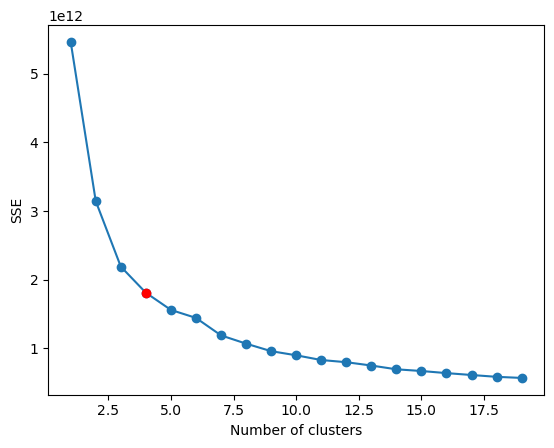

In [49]:
sse = [] # Sum of Squared Error of data points to centroid; The smaller the better.
for i in range(1, 20): # get the prefect number of clusters from 1 to 20
    loan_kmeans = KMeans(n_clusters = i, random_state = 42)
    loan_kmeans.fit(X_test)
    sse.append(loan_kmeans.inertia_)
    
plt.plot(range(1, 20), sse, marker = 'o')
plt.plot(4, sse[3], color = 'r', marker = 'o') # plot red mark on k = 4
plt.xlabel('Number of clusters')
plt.ylabel('SSE')
plt.show()

In [50]:
loan_kmeans_4 = KMeans(n_clusters = 4, random_state = 1)
loan_kmeans_4.fit(X_test)
#loan_kmeans_4.labels_

KMeans(n_clusters=4, random_state=1)

In [51]:
X_test['cluster'] = loan_kmeans_4.labels_
print(X_test['cluster'].value_counts())
X_test.describe()

cluster
0    1165
3     698
1     127
2      10
Name: count, dtype: int64


,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,home_ownership,annual_inc,verification_status,...,total_rec_int,total_rec_late_fee,last_pymnt_amnt,collections_12_mths_ex_med,policy_code,acc_now_delinq,pymnt_plan_ind,initial_list_status_ind,application_type_ind,cluster
count,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,...,2000.000000,2000.000000,2000.000000,2000.000000,2000.0,2000.000000,2000.0,2000.000000,2000.000000,2000.000000
mean,14608.250000,14566.31250,14424.432857,43.908000,14.416235,435.798000,2.111500,2.003500,70465.197240,1.058000,...,1969.585905,1.695033,1358.659465,0.015500,1.0,0.007500,0.0,0.403500,0.001000,1.120500
std,8423.664456,8407.40523,8466.633804,11.283581,4.480446,246.644399,1.386373,1.928302,44678.961883,0.803716,...,2225.887491,8.610428,3589.900731,0.135162,0.0,0.091913,0.0,0.490722,0.031615,1.403554
min,1000.000000,1000.00000,0.000000,36.000000,5.320000,33.690000,0.000000,0.000000,9600.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,0.0,0.000000,0.000000,0.000000
25%,8000.000000,8000.00000,8000.000000,36.000000,11.490000,260.110000,1.000000,0.000000,42000.000000,0.000000,...,533.382500,0.000000,272.197500,0.000000,1.0,0.000000,0.0,0.000000,0.000000,0.000000
50%,13000.000000,13000.00000,12800.000000,36.000000,13.990000,385.000000,2.000000,3.000000,60000.000000,1.000000,...,1246.395000,0.000000,425.025000,0.000000,1.0,0.000000,0.0,0.000000,0.000000,0.000000
75%,20000.000000,20000.00000,20000.000000,60.000000,17.570000,564.795000,3.000000,4.000000,85000.000000,2.000000,...,2534.585000,0.000000,669.125000,0.000000,1.0,0.000000,0.0,1.000000,0.000000,3.000000
max,35000.000000,35000.00000,35000.000000,60.000000,27.310000,1408.130000,6.000000,4.000000,560000.000000,2.000000,...,17490.240000,139.560000,32235.420000,2.000000,1.0,2.000000,0.0,1.000000,1.000000,3.000000


In [52]:
var_names = []
for col in X_test.columns:
    if col == "home_ownership" in col:
        var_names.append(col)
        X_test[col]
X_test[["home_ownership"]].describe()

,home_ownership
count,2000.000000
mean,2.003500
std,1.928302
min,0.000000
25%,0.000000
50%,3.000000
75%,4.000000
max,4.000000


In [53]:
pd.set_option('display.max_rows', 100)
group = X_test.groupby('cluster').mean().T
group

cluster,0,1,2,3
loan_amnt,10746.394850,22713.976378,22042.500,19472.564470
funded_amnt,10710.472103,22578.937008,22042.500,19436.926934
funded_amnt_inv,10594.226608,22173.048459,22010.345,19298.726520
term,42.283262,43.937008,40.800,46.659026
int_rate,14.483571,13.121575,14.277,14.541404
installment,329.417923,675.374724,713.197,565.787335
grade,2.098712,1.795276,2.000,2.191977
home_ownership,2.388841,1.110236,0.400,1.545845
annual_inc,45313.830712,173193.818898,384499.600,89253.826218
verification_status,0.965665,1.244094,1.100,1.177650
